# 1. Importing Libraries

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os


# 2. Loading and Merging Datasets

In [2]:
import pandas as pd
import os

# Define the base path
base_path = "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv"

# Check if the path exists
if os.path.exists(base_path):
    # List all files in the directory
    all_files = os.listdir(base_path)
    
    # Filter only CSV files
    csv_files = [f for f in all_files if f.endswith('.csv')]
    
    if csv_files:
        print(f"Found {len(csv_files)} CSV files in {base_path}\n")
        
        # Loop through each CSV file
        for file_name in csv_files:
            file_path = os.path.join(base_path, file_name)
            
            try:
                # Load the dataset into pandas dataframe with low_memory=False to avoid dtype warning
                df = pd.read_csv(file_path, low_memory=False)
                
                # Get the shape (number of rows and columns)
                rows, cols = df.shape
                
                print(f"File: {file_name}")
                print(f"  Full Path: {file_path}")
                print(f"  Matrix Size: {rows:,} rows x {cols} columns\n")
                
            except Exception as e:
                print(f"Error reading {file_name}: {e}\n")
    else:
        print(f"No CSV files found in {base_path}")
else:
    print(f"Path {base_path} does not exist.")
    
    # Alternative: Try to find the correct path
    print("\nTrying alternative paths...")
    
    # List possible alternative paths
    alternative_paths = [
        "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv",
        "/kaggle/input/ids-intrusion-csv",
        "/kaggle/input/solarmainframe/ids-intrusion-csv"
    ]
    
    for alt_path in alternative_paths:
        if os.path.exists(alt_path):
            print(f"Found alternative path: {alt_path}")
            csv_files = [f for f in os.listdir(alt_path) if f.endswith('.csv')]
            if csv_files:
                for file_name in csv_files:
                    file_path = os.path.join(alt_path, file_name)
                    try:
                        df = pd.read_csv(file_path, low_memory=False)
                        rows, cols = df.shape
                        print(f"  {file_name}: {rows:,} rows x {cols} columns")
                    except Exception as e:
                        print(f"  Error reading {file_name}: {e}")
            break

Found 10 CSV files in /kaggle/input/datasets/solarmainframe/ids-intrusion-csv

File: 02-28-2018.csv
  Full Path: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-28-2018.csv
  Matrix Size: 613,104 rows x 80 columns

File: 03-01-2018.csv
  Full Path: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/03-01-2018.csv
  Matrix Size: 331,125 rows x 80 columns

File: 02-16-2018.csv
  Full Path: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-16-2018.csv
  Matrix Size: 1,048,575 rows x 80 columns

File: 02-15-2018.csv
  Full Path: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-15-2018.csv
  Matrix Size: 1,048,575 rows x 80 columns

File: 02-21-2018.csv
  Full Path: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-21-2018.csv
  Matrix Size: 1,048,575 rows x 80 columns

File: 03-02-2018.csv
  Full Path: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/03-02-2018.csv
  Matrix Size: 1,048,575 rows x 80 columns

File: 02-22-2018.csv
  Full Pat

In [3]:
import pandas as pd
import os
import numpy as np

# Define the base path
base_path = "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv"

# Get all CSV files
all_files = [f for f in os.listdir(base_path) if f.endswith('.csv')]
all_paths = [os.path.join(base_path, f) for f in all_files]

def process_data_files(base_path, sample_fraction=0.25, random_state=42):
    """
    Unified method for processing data files with column matching validation and weighted sampling
    
    Parameters:
    -----------
    base_path : str
        Path to the directory containing CSV files
    sample_fraction : float
        Fraction of rows to sample from each file (default: 0.25)
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    dict : Dictionary containing processed data and metadata
    """
    
    print("="*80)
    print("DATASET ANALYSIS AND PROCESSING")
    print("="*80)
    
    # Step 1: Identify column counts for all files
    file_info = []
    for file_path in all_paths:
        try:
            df_sample = pd.read_csv(file_path, nrows=5)
            file_info.append({
                'file_name': os.path.basename(file_path),
                'full_path': file_path,
                'columns': len(df_sample.columns),
                'column_names': list(df_sample.columns)
            })
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    
    # Step 2: Identify column mode (most common column count)
    column_counts = [info['columns'] for info in file_info]
    if not column_counts:
        print("No valid files found.")
        return None
    
    from collections import Counter
    column_mode = Counter(column_counts).most_common(1)[0][0]
    
    print(f"\nColumn count distribution:")
    for count, freq in Counter(column_counts).items():
        print(f"  {count} columns: {freq} file(s)")
    
    # Step 3: Filter files that match the mode (most common column count)
    matching_files = [info for info in file_info if info['columns'] == column_mode]
    mismatched_files = [info for info in file_info if info['columns'] != column_mode]
    
    print(f"\n" + "="*80)
    print("COLUMN CONSISTENCY ANALYSIS")
    print("="*80)
    print(f"Using column mode: {column_mode} columns")
    print(f"Files with matching columns: {len(matching_files)}")
    for info in matching_files:
        print(f"  ✓ {info['file_name']}")
    
    print(f"\nIgnored files (column mismatch): {len(mismatched_files)}")
    for info in mismatched_files:
        print(f"  ✗ {info['file_name']}: {info['columns']} columns")
    
    # Step 4: Process matching files with weighted sampling
    if not matching_files:
        print("\nNo matching files found. Exiting.")
        return None
    
    print(f"\n" + "="*80)
    print(f"PROCESSING WITH WEIGHTED SAMPLING (using {sample_fraction*100}% of each file)")
    print("="*80)
    
    processed_dataframes = []
    metadata = {
        'total_files': len(matching_files),
        'sample_fraction': sample_fraction,
        'column_mode': column_mode,
        'files_processed': [],
        'total_original_rows': 0,
        'total_sampled_rows': 0
    }
    
    for info in matching_files:
        try:
            # Load the full dataset
            df = pd.read_csv(info['full_path'], low_memory=False)
            original_rows = len(df)
            metadata['total_original_rows'] += original_rows
            
            # Calculate sample size (1/4 of original rows)
            sample_size = int(original_rows * sample_fraction)
            
            # Perform weighted sampling
            sampled_df = df.sample(n=sample_size, random_state=random_state)
            sampled_rows = len(sampled_df)
            metadata['total_sampled_rows'] += sampled_rows
            
            # Store file information
            metadata['files_processed'].append({
                'file_name': info['file_name'],
                'original_rows': original_rows,
                'sampled_rows': sampled_rows,
                'sampling_fraction': sample_fraction
            })
            
            processed_dataframes.append(sampled_df)
            
            print(f"  {info['file_name']}:")
            print(f"    Original: {original_rows:,} rows")
            print(f"    Sampled: {sampled_rows:,} rows ({sample_fraction*100}%)")
            
        except Exception as e:
            print(f"  Error processing {info['file_name']}: {e}")
    
    # Step 5: Concatenate all processed dataframes
    if processed_dataframes:
        merged_df = pd.concat(processed_dataframes, ignore_index=True)
        
        print(f"\n" + "="*80)
        print("MERGE RESULTS")
        print("="*80)
        print(f"Final merged dataset shape: {merged_df.shape[0]:,} rows x {merged_df.shape[1]} columns")
        print(f"Total original rows across all files: {metadata['total_original_rows']:,}")
        print(f"Total sampled rows: {metadata['total_sampled_rows']:,}")
        print(f"Overall sampling rate: {metadata['total_sampled_rows']/metadata['total_original_rows']*100:.1f}%")
        
        # Memory usage
        memory_usage = merged_df.memory_usage(deep=True).sum() / (1024**3)
        print(f"Memory usage: {memory_usage:.2f} GB")
        
        return {
            'data': merged_df,
            'metadata': metadata
        }
    else:
        print("\nNo dataframes were successfully processed.")
        return None

# Execute the processing
result = process_data_files(base_path, sample_fraction=0.25)

# Save the processed data if successful
if result:
    print("\n" + "="*80)
    print("SAVING RESULTS")
    print("="*80)
    
    # Save the merged dataset
    output_path = '/kaggle/working/processed_merged_dataset.csv'
    result['data'].to_csv(output_path, index=False)
    print(f"✓ Merged dataset saved to: {output_path}")
    
    # Save metadata summary
    metadata_path = '/kaggle/working/processing_metadata.txt'
    with open(metadata_path, 'w') as f:
        f.write("DATASET PROCESSING METADATA\n")
        f.write("="*50 + "\n")
        f.write(f"Processing Date: {pd.Timestamp.now()}\n")
        f.write(f"Column mode used: {result['metadata']['column_mode']}\n")
        f.write(f"Sample fraction: {result['metadata']['sample_fraction']*100}%\n")
        f.write(f"Total original rows: {result['metadata']['total_original_rows']:,}\n")
        f.write(f"Total sampled rows: {result['metadata']['total_sampled_rows']:,}\n")
        f.write(f"Final dataset shape: {result['data'].shape}\n\n")
        f.write("FILES PROCESSED:\n")
        f.write("-"*50 + "\n")
        for file_info in result['metadata']['files_processed']:
            f.write(f"{file_info['file_name']}:\n")
            f.write(f"  Original: {file_info['original_rows']:,} rows\n")
            f.write(f"  Sampled: {file_info['sampled_rows']:,} rows ({file_info['sampling_fraction']*100}%)\n\n")
    
    print(f"✓ Metadata saved to: {metadata_path}")
    
    # Display sample of the merged data
    print("\n" + "="*80)
    print("DATA SAMPLE (first 5 rows)")
    print("="*80)
    print(result['data'].head())
    
    # Display data types and basic info
    print("\n" + "="*80)
    print("DATA INFORMATION")
    print("="*80)
    print(f"Column names: {list(result['data'].columns)}")
    print(f"\nData types summary:")
    print(result['data'].dtypes.value_counts())

DATASET ANALYSIS AND PROCESSING

Column count distribution:
  80 columns: 9 file(s)
  84 columns: 1 file(s)

COLUMN CONSISTENCY ANALYSIS
Using column mode: 80 columns
Files with matching columns: 9
  ✓ 02-28-2018.csv
  ✓ 03-01-2018.csv
  ✓ 02-16-2018.csv
  ✓ 02-15-2018.csv
  ✓ 02-21-2018.csv
  ✓ 03-02-2018.csv
  ✓ 02-22-2018.csv
  ✓ 02-14-2018.csv
  ✓ 02-23-2018.csv

Ignored files (column mismatch): 1
  ✗ 02-20-2018.csv: 84 columns

PROCESSING WITH WEIGHTED SAMPLING (using 25.0% of each file)
  02-28-2018.csv:
    Original: 613,104 rows
    Sampled: 153,276 rows (25.0%)
  03-01-2018.csv:
    Original: 331,125 rows
    Sampled: 82,781 rows (25.0%)
  02-16-2018.csv:
    Original: 1,048,575 rows
    Sampled: 262,143 rows (25.0%)
  02-15-2018.csv:
    Original: 1,048,575 rows
    Sampled: 262,143 rows (25.0%)
  02-21-2018.csv:
    Original: 1,048,575 rows
    Sampled: 262,143 rows (25.0%)
  03-02-2018.csv:
    Original: 1,048,575 rows
    Sampled: 262,143 rows (25.0%)
  02-22-2018.csv:
   

# 3. Analyzing the Data (Correlations, Missing Values)

LOADING DATASET
Dataset loaded: 2,071,058 rows x 80 columns

LABEL DISTRIBUTION
Label
Benign                      1528141
DDOS attack-HOIC             171507
DoS attacks-Hulk             115491
Bot                           71566
FTP-BruteForce                48232
SSH-Bruteforce                47064
Infilteration                 40491
DoS attacks-SlowHTTPTest      34821
DoS attacks-GoldenEye         10325
DoS attacks-Slowloris          2742
DDOS attack-LOIC-UDP            438
Brute Force -Web                141
Brute Force -XSS                 61
SQL Injection                    23
Label                            15
Name: count, dtype: int64

Total classes: 15


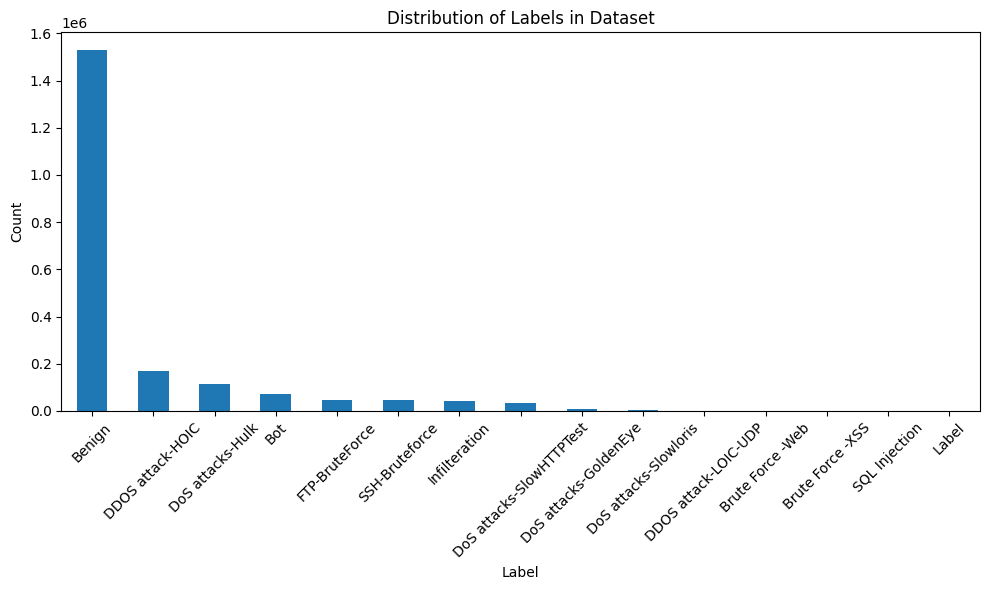


MISSING VALUES ANALYSIS
             Missing Count  Missing Percentage
Flow Byts/s           5787            0.279422

Handling missing values...
Dropped 8853 rows with missing values
Dataset shape after cleaning: (2062205, 80)

TIMESTAMP PROCESSING
Added features: Hour, DayOfWeek, Month
Time range: 3600.0 to 46799.0 seconds
Date range: 4.0 to 17592.0 days

LABEL ENCODING
Label mapping:
  Benign -> 0
  Bot -> 1
  Brute Force -Web -> 2
  Brute Force -XSS -> 3
  DDOS attack-HOIC -> 4
  DDOS attack-LOIC-UDP -> 5
  DoS attacks-GoldenEye -> 6
  DoS attacks-Hulk -> 7
  DoS attacks-SlowHTTPTest -> 8
  DoS attacks-Slowloris -> 9
  FTP-BruteForce -> 10
  Infilteration -> 11
  Label -> 12
  SQL Injection -> 13
  SSH-Bruteforce -> 14

Label Encoding Mapping:
              Original Label  Encoded Value
0                     Benign              0
1                        Bot              1
2           Brute Force -Web              2
3           Brute Force -XSS              3
4           DDOS atta

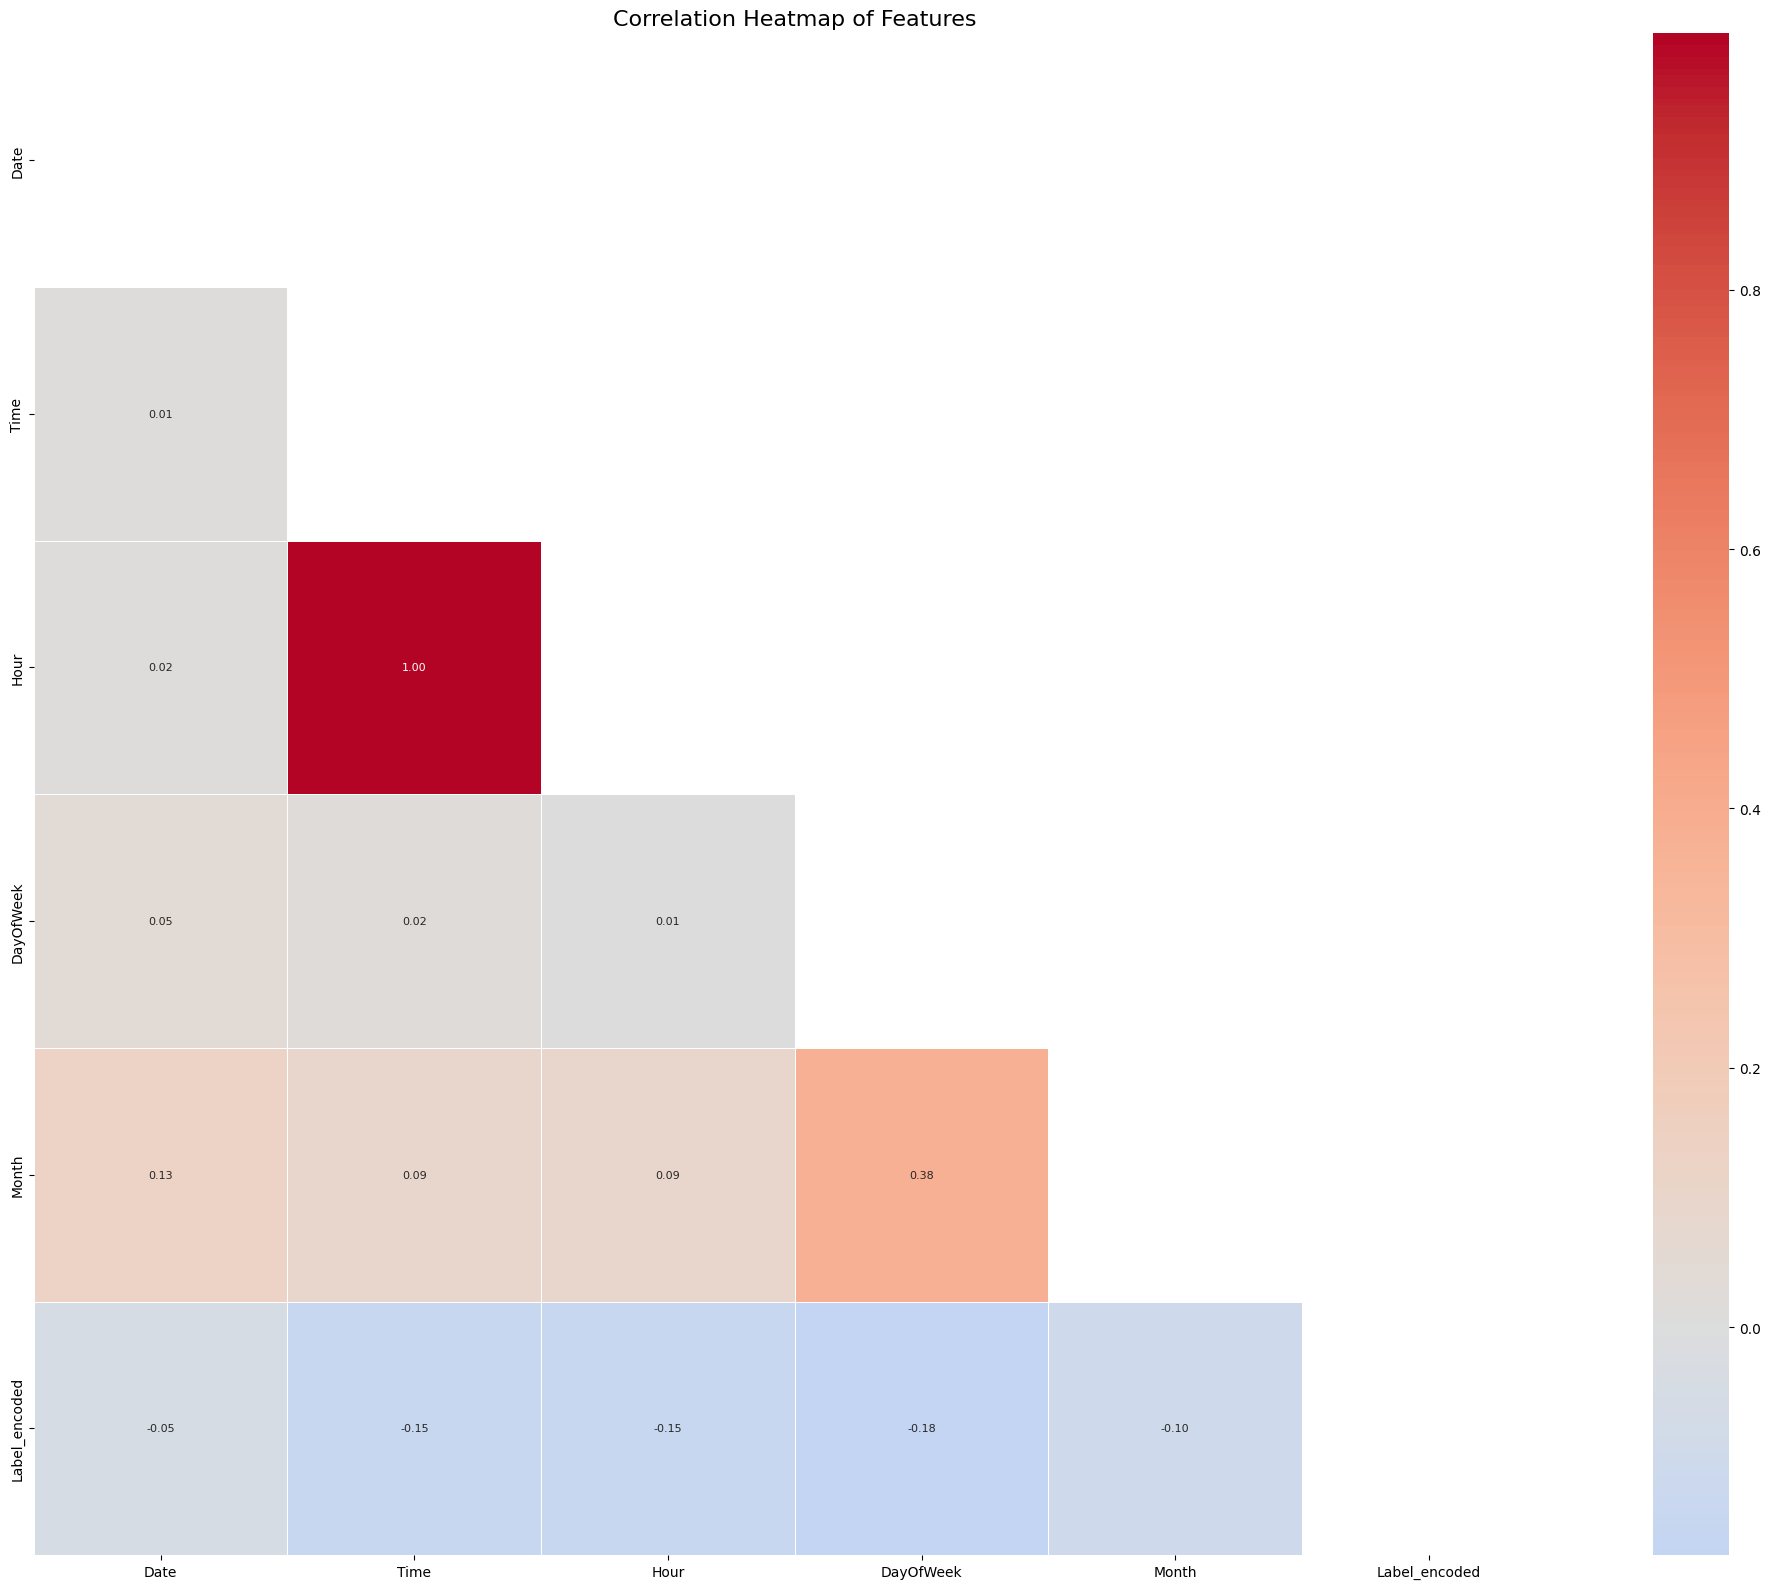


Top 10 Features Correlated with Target:
Label_encoded    1.000000
Date            -0.046538
Month           -0.098571
Time            -0.150814
Hour            -0.151707
DayOfWeek       -0.175869
Name: Label_encoded, dtype: float64

Processed dataset saved to '/kaggle/working/processed_dataset.csv'


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load the merged consistent dataset
print("="*80)
print("LOADING DATASET")
print("="*80)
final_df = pd.read_csv('/kaggle/working/processed_merged_dataset.csv')
print(f"Dataset loaded: {final_df.shape[0]:,} rows x {final_df.shape[1]} columns")

# Display label distribution
print("\n" + "="*80)
print("LABEL DISTRIBUTION")
print("="*80)
label_counts = final_df['Label'].value_counts()
print(label_counts)
print(f"\nTotal classes: {len(label_counts)}")

# Visualize label distribution
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Distribution of Labels in Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Check for missing values
print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)
missing_values = final_df.isnull().sum()
missing_percentage = (missing_values / len(final_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

# Handle missing values
print("\nHandling missing values...")
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)
initial_rows = len(final_df)
final_df.dropna(inplace=True)
print(f"Dropped {initial_rows - len(final_df)} rows with missing values")
print(f"Dataset shape after cleaning: {final_df.shape}")

# Process Timestamp column
print("\n" + "="*80)
print("TIMESTAMP PROCESSING")
print("="*80)
if 'Timestamp' in final_df.columns:
    final_df['Timestamp'] = pd.to_datetime(final_df['Timestamp'], errors='coerce')
    
    # Create date and time features
    final_df['Date'] = final_df['Timestamp'].dt.date
    final_df['Time'] = final_df['Timestamp'].dt.time
    final_df['Hour'] = final_df['Timestamp'].dt.hour
    final_df['DayOfWeek'] = final_df['Timestamp'].dt.dayofweek
    final_df['Month'] = final_df['Timestamp'].dt.month
    
    # Convert date to numerical
    final_df['Date'] = (pd.to_datetime(final_df['Date']) - pd.Timestamp("1970-01-01")).dt.days
    
    # Convert time to seconds since midnight
    final_df['Time'] = final_df['Timestamp'].dt.hour * 3600 + \
                       final_df['Timestamp'].dt.minute * 60 + \
                       final_df['Timestamp'].dt.second
    
    # Drop original timestamp
    final_df.drop('Timestamp', axis=1, inplace=True)
    
    print("Added features: Hour, DayOfWeek, Month")
    print(f"Time range: {final_df['Time'].min()} to {final_df['Time'].max()} seconds")
    print(f"Date range: {final_df['Date'].min()} to {final_df['Date'].max()} days")

# Encode labels
print("\n" + "="*80)
print("LABEL ENCODING")
print("="*80)
label_encoder = LabelEncoder()
final_df['Label_encoded'] = label_encoder.fit_transform(final_df['Label'])
print("Label mapping:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {idx}")

# Display label encoding summary
label_mapping_df = pd.DataFrame({
    'Original Label': label_encoder.classes_,
    'Encoded Value': range(len(label_encoder.classes_))
})
print("\nLabel Encoding Mapping:")
print(label_mapping_df)

# Rearrange columns to put encoded label last
columns = [col for col in final_df.columns if col not in ['Label', 'Label_encoded']]
final_df = final_df[columns + ['Label', 'Label_encoded']]

# Correlation analysis
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)
numeric_df = final_df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap with target variable
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", 
            cmap="coolwarm", linewidths=0.5, center=0,
            square=True, annot_kws={"size": 8})
plt.title("Correlation Heatmap of Features", fontsize=16)
plt.tight_layout()
plt.show()

# Show top correlations with target
target_corr = correlation_matrix['Label_encoded'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Target:")
print(target_corr.head(11))

# Save processed dataset
final_df.to_csv('/kaggle/working/processed_dataset.csv', index=False)
print("\nProcessed dataset saved to '/kaggle/working/processed_dataset.csv'")

# 4. Preparing the Data for Machine Learning

In [8]:
# ============================================================================
# SECTION 4: PREPARING DATA FOR MACHINE LEARNING (MEMORY-OPTIMIZED)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
import gc
import os
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("PREPARING DATA FOR MACHINE LEARNING (MEMORY-OPTIMIZED)")
print("="*80)

# Load the processed dataset with memory optimization
print("Loading dataset...")

# Define file path
file_path = '/kaggle/working/processed_dataset.csv'

# Check if file exists, if not check alternative path
if not os.path.exists(file_path):
    file_path = '/kaggle/working/processed_merged_dataset.csv'
    print(f"Using alternative file: {file_path}")

# Check file size
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"File size: {file_size_mb:.2f} MB")

# Read the entire dataset without sampling
print("Loading entire dataset...")
final_df = pd.read_csv(file_path, low_memory=False)

print(f"\nDataset loaded: {final_df.shape[0]:,} rows x {final_df.shape[1]} columns")

# Check for and remove duplicate columns
print("\nChecking for duplicate columns...")
duplicate_cols = []
seen_columns = {}
for col in final_df.columns:
    if col in seen_columns:
        duplicate_cols.append(col)
        print(f"  Found duplicate column: {col}")
    else:
        seen_columns[col] = 1

if duplicate_cols:
    print(f"Dropping {len(duplicate_cols)} duplicate columns...")
    final_df = final_df.loc[:, ~final_df.columns.duplicated()]
    print(f"New shape after removing duplicates: {final_df.shape}")

# Downcast numeric columns to save memory
print("\nOptimizing data types...")
for col in final_df.columns:
    col_type = final_df[col].dtype
    
    if col_type != 'object':
        if col_type in ['int64']:
            # Downcast integers
            final_df[col] = pd.to_numeric(final_df[col], downcast='integer')
        elif col_type in ['float64']:
            # Downcast floats
            final_df[col] = pd.to_numeric(final_df[col], downcast='float')
    else:
        # Convert object columns to category if they have few unique values
        unique_count = final_df[col].nunique()
        if unique_count < 0.5 * len(final_df):  # Less than 50% unique
            final_df[col] = final_df[col].astype('category')

# Calculate memory usage after optimization
memory_usage_mb = final_df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memory usage after optimization: {memory_usage_mb:.2f} MB")

# Prepare features and target
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Identify the label column
label_column = None
for col in final_df.columns:
    if col.lower() in ['label', 'labels', 'attack', 'class', 'type']:
        label_column = col
        break

if label_column is None:
    print("Error: Label column not found in dataset")
    print(f"Available columns: {final_df.columns.tolist()[:20]}...")
    raise KeyError("Label column missing")

print(f"Using '{label_column}' as target column")

# Encode labels
print("Encoding target labels...")
label_encoder = LabelEncoder()
final_df['Label_encoded'] = label_encoder.fit_transform(final_df[label_column])

# Get class distribution
print("\nTarget distribution:")
for i, label in enumerate(label_encoder.classes_):
    count = (final_df['Label_encoded'] == i).sum()
    print(f"  {label}: {count:,} samples ({count/len(final_df)*100:.2f}%)")

# Separate features and target
print("\nSeparating features and target...")
X = final_df.drop([label_column, 'Label_encoded'], axis=1)
y = final_df['Label_encoded'].values

# Store feature names before any transformations
feature_names = X.columns.tolist()

# Convert categorical columns to numeric
categorical_cols = X.select_dtypes(include=['category', 'object']).columns
if len(categorical_cols) > 0:
    print(f"\nConverting {len(categorical_cols)} categorical columns to numeric...")
    for col in categorical_cols:
        try:
            X[col] = X[col].astype('category').cat.codes
            if len(categorical_cols) <= 10:  # Only print if few columns
                print(f"  Converted {col}")
        except Exception as e:
            print(f"  Error converting {col}: {e}")
            X[col] = X[col].fillna('unknown').astype('category').cat.codes
    
    if len(categorical_cols) > 10:
        print(f"  Converted all {len(categorical_cols)} categorical columns")

# Ensure all features are numeric
print("\nConverting all features to float32...")
X = X.astype(np.float32)

# Handle any remaining NaN values
print(f"\nChecking for NaN values...")
nan_cols = X.columns[X.isnull().any()].tolist()
if nan_cols:
    print(f"  {len(nan_cols)} columns have NaN values: {nan_cols[:5]}...")
    print("  Dropping rows with NaN values...")
    rows_before = len(X)
    # Keep track of which rows to drop
    nan_mask = X.isnull().any(axis=1)
    X = X[~nan_mask]
    y = y[~nan_mask]
    print(f"  Dropped {rows_before - len(X):,} rows")
else:
    print("  No NaN values found")

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Verify shapes match
assert X.shape[0] == y.shape[0], f"Shape mismatch: X has {X.shape[0]} rows, y has {len(y)} rows"

# Split the data
print("\n" + "="*80)
print("SPLITTING DATA")
print("="*80)
print("Splitting data into train (70%) and test (30%)...")

# Use 70-30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

# Standardize features with incremental processing
print("\n" + "="*80)
print("FEATURE STANDARDIZATION")
print("="*80)

# Convert to numpy arrays for efficiency
X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

# Initialize scaler
scaler = StandardScaler()

# Fit on training data
print("Fitting scaler on training data...")
scaler.fit(X_train)

# Transform in batches to save memory
print("Transforming training data...")
X_train_scaled = scaler.transform(X_train)

print("Transforming test data...")
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

# Data validation
print("\n" + "="*80)
print("DATA VALIDATION")
print("="*80)

has_nan = np.isnan(X_train_scaled).any()
has_inf = np.isinf(X_train_scaled).any()

print(f"NaN values in training data: {'No' if not has_nan else 'Yes'}")
print(f"Infinite values in training data: {'No' if not has_inf else 'Yes'}")

# Check for class imbalance in training set
print("\nClass distribution in training set:")
train_class_dist = pd.Series(y_train).value_counts().sort_index()
for i in range(len(label_encoder.classes_)):
    if i in train_class_dist.index:
        count = train_class_dist[i]
        print(f"  {label_encoder.classes_[i]}: {count:,} samples ({count/len(y_train)*100:.2f}%)")
    else:
        print(f"  {label_encoder.classes_[i]}: 0 samples (0.00%)")

# Save preprocessing objects
import joblib
print("\nSaving preprocessing objects...")
joblib.dump(scaler, '/kaggle/working/scaler.pkl')
joblib.dump(label_encoder, '/kaggle/working/label_encoder.pkl')
joblib.dump(feature_names, '/kaggle/working/feature_names.pkl')
print("Preprocessing objects saved")

# Save the processed data for model training
print("\nSaving processed datasets...")
np.save('/kaggle/working/X_train_scaled.npy', X_train_scaled)
np.save('/kaggle/working/X_test_scaled.npy', X_test_scaled)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/y_test.npy', y_test)
print("Processed datasets saved as numpy arrays")

# Save training metadata
metadata = {
    'total_samples': len(y_train) + len(y_test),
    'train_samples': len(y_train),
    'test_samples': len(y_test),
    'features_count': X_train_scaled.shape[1],
    'classes': label_encoder.classes_.tolist(),
    'class_counts': {label: int(count) for label, count in zip(label_encoder.classes_, 
                                                               np.bincount(y))}
}
import json
with open('/kaggle/working/training_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Training metadata saved")

# Display feature names before cleanup
print("\nFirst 10 features:")
for i, feature in enumerate(feature_names[:10]):
    print(f"  {i+1}. {feature}")

print(f"\nLast 5 features:")
for i, feature in enumerate(feature_names[-5:], start=len(feature_names)-4):
    print(f"  {i}. {feature}")

# Memory cleanup
print("\n" + "="*80)
print("MEMORY CLEANUP")
print("="*80)

# Delete large objects
del X, y, final_df
del X_train, X_test
gc.collect()

print("Cleared unnecessary variables from memory")

# Final summary
print("\n" + "="*80)
print("DATA PREPARATION COMPLETE")
print("="*80)
print(f"Total samples: {metadata['total_samples']:,}")
print(f"Features: {metadata['features_count']}")
print(f"Training samples: {metadata['train_samples']:,} (70%)")
print(f"Test samples: {metadata['test_samples']:,} (30%)")
print(f"Number of classes: {len(metadata['classes'])}")
print(f"Features scaled: Yes (StandardScaler)")
print(f"Data types: float32")
print("Data ready for model training: Yes")
print("\nFiles saved:")
print("  - scaler.pkl (StandardScaler object)")
print("  - label_encoder.pkl (LabelEncoder object)")
print("  - feature_names.pkl (List of feature names)")
print("  - X_train_scaled.npy (Training features)")
print("  - X_test_scaled.npy (Test features)")
print("  - y_train.npy (Training labels)")
print("  - y_test.npy (Test labels)")
print("  - training_metadata.json (Dataset information)")
print("\nModel training can now begin...")


PREPARING DATA FOR MACHINE LEARNING (MEMORY-OPTIMIZED)
Loading dataset...
File size: 751.07 MB
Loading entire dataset...

Dataset loaded: 2,062,205 rows x 85 columns

Checking for duplicate columns...

Optimizing data types...
Memory usage after optimization: 1678.68 MB

DATA PREPARATION
Using 'Label' as target column
Encoding target labels...

Target distribution:
  Benign: 1,519,575 samples (73.69%)
  Bot: 71,566 samples (3.47%)
  Brute Force -Web: 141 samples (0.01%)
  Brute Force -XSS: 61 samples (0.00%)
  DDOS attack-HOIC: 171,507 samples (8.32%)
  DDOS attack-LOIC-UDP: 438 samples (0.02%)
  DoS attacks-GoldenEye: 10,325 samples (0.50%)
  DoS attacks-Hulk: 115,491 samples (5.60%)
  DoS attacks-SlowHTTPTest: 34,821 samples (1.69%)
  DoS attacks-Slowloris: 2,742 samples (0.13%)
  FTP-BruteForce: 48,229 samples (2.34%)
  Infilteration: 40,207 samples (1.95%)
  Label: 15 samples (0.00%)
  SQL Injection: 23 samples (0.00%)
  SSH-Bruteforce: 47,064 samples (2.28%)

Separating features 

# SECTION 5: MODEL TRAINING AND EVALUATION


MODEL TRAINING AND EVALUATION
Loading preprocessing objects...
Loading processed data...
Training data shape: (1443533, 83)
Test data shape: (618657, 83)

Classes in training set: 14
Classes in test set: 14

Present classes in test set: ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce']

Training Random Forest...

Random Forest Performance:
Accuracy: 0.9899
Precision: 0.9891
Recall: 0.9899
F1-Score: 0.9893

Classification Report (only classes with test samples):
                          precision    recall  f1-score   support

                  Benign       0.99      1.00      0.99    455873
                     Bot       1.00      1.00      1.00     21470
        Brute Force -Web       1.00      0.64      0.78        42
        Brute Force -XSS       1.00      0.72   

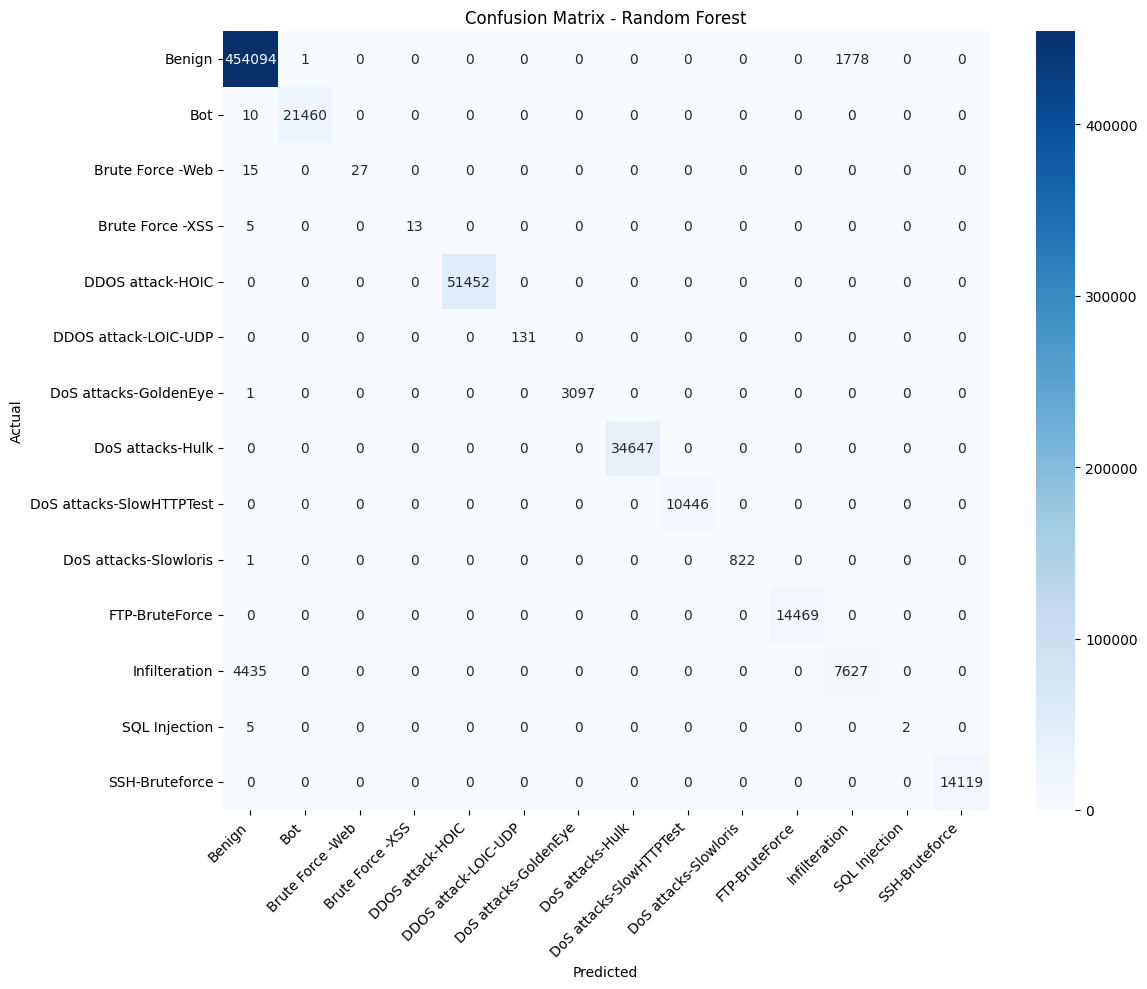


Training Decision Tree...

Decision Tree Performance:
Accuracy: 0.9916
Precision: 0.9916
Recall: 0.9916
F1-Score: 0.9916

Classification Report (only classes with test samples):
                          precision    recall  f1-score   support

                  Benign       0.99      0.99      0.99    455873
                     Bot       1.00      1.00      1.00     21470
        Brute Force -Web       0.90      0.86      0.88        42
        Brute Force -XSS       0.95      1.00      0.97        18
        DDOS attack-HOIC       1.00      1.00      1.00     51452
    DDOS attack-LOIC-UDP       1.00      1.00      1.00       131
   DoS attacks-GoldenEye       1.00      1.00      1.00      3098
        DoS attacks-Hulk       1.00      1.00      1.00     34647
DoS attacks-SlowHTTPTest       1.00      1.00      1.00     10446
   DoS attacks-Slowloris       1.00      1.00      1.00       823
          FTP-BruteForce       1.00      1.00      1.00     14469
           Infilteration    

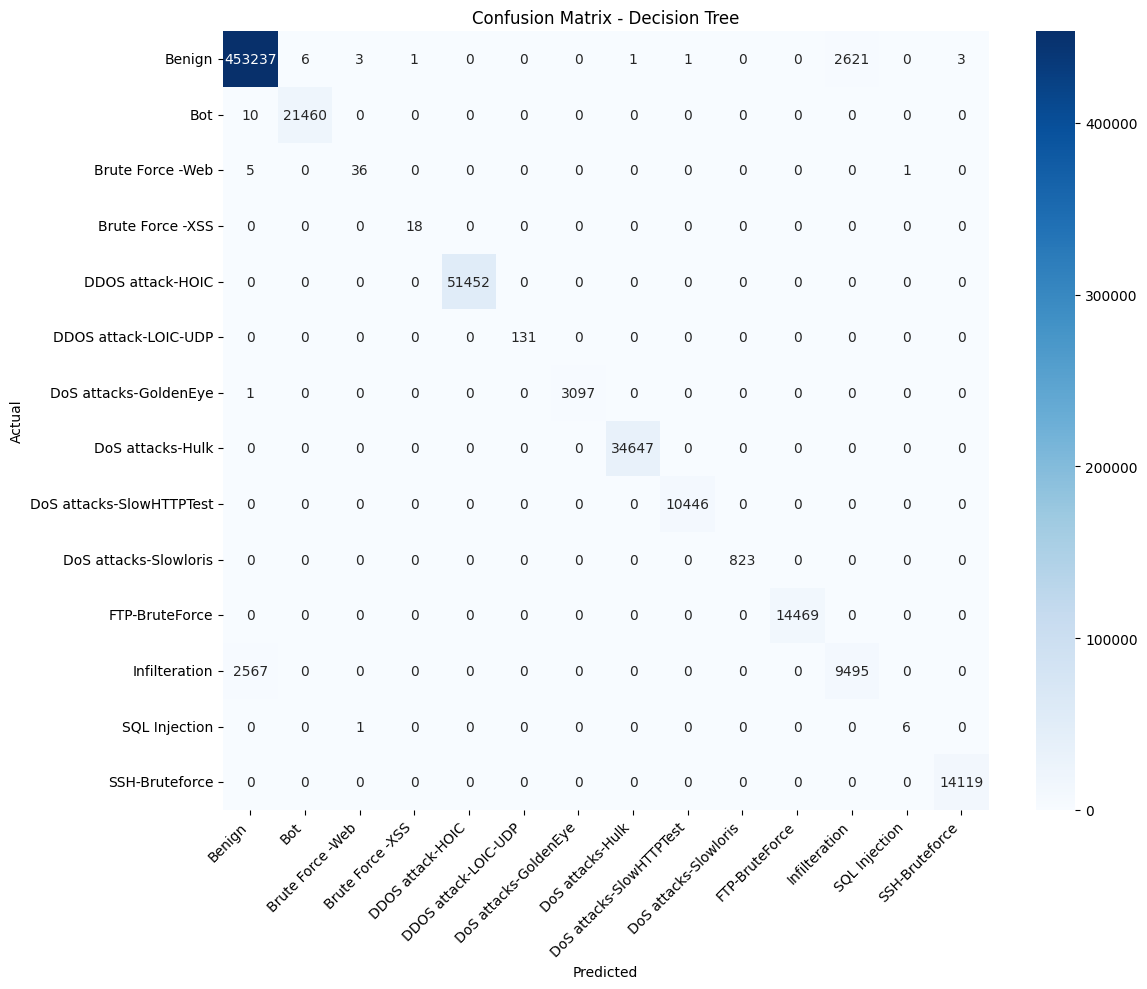


Training Logistic Regression...

Logistic Regression Performance:
Accuracy: 0.9798
Precision: 0.9775
Recall: 0.9798
F1-Score: 0.9711

Classification Report (only classes with test samples):
                          precision    recall  f1-score   support

                  Benign       0.97      1.00      0.99    455873
                     Bot       0.99      1.00      0.99     21470
        Brute Force -Web       0.90      0.43      0.58        42
        Brute Force -XSS       1.00      0.61      0.76        18
        DDOS attack-HOIC       0.99      1.00      1.00     51452
    DDOS attack-LOIC-UDP       0.99      1.00      1.00       131
   DoS attacks-GoldenEye       1.00      1.00      1.00      3098
        DoS attacks-Hulk       1.00      1.00      1.00     34647
DoS attacks-SlowHTTPTest       1.00      1.00      1.00     10446
   DoS attacks-Slowloris       0.99      1.00      0.99       823
          FTP-BruteForce       1.00      1.00      1.00     14469
           Infil

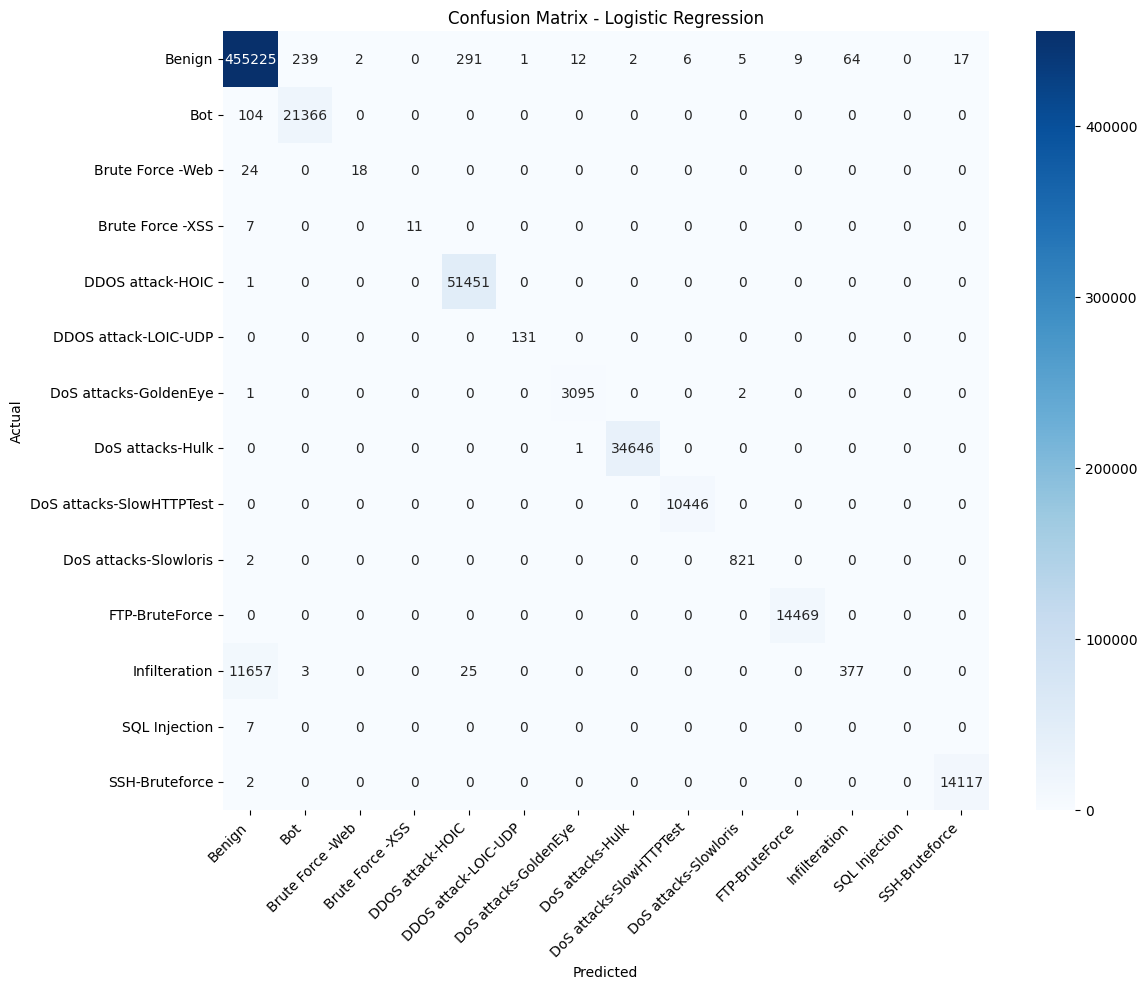


Training MLP Classifier...

MLP Classifier Performance:
Accuracy: 0.9870
Precision: 0.9856
Recall: 0.9870
F1-Score: 0.9859

Classification Report (only classes with test samples):
                          precision    recall  f1-score   support

                  Benign       0.99      1.00      0.99    455873
                     Bot       1.00      1.00      1.00     21470
        Brute Force -Web       0.93      0.98      0.95        42
        Brute Force -XSS       1.00      0.83      0.91        18
        DDOS attack-HOIC       1.00      1.00      1.00     51452
    DDOS attack-LOIC-UDP       1.00      0.98      0.99       131
   DoS attacks-GoldenEye       1.00      1.00      1.00      3098
        DoS attacks-Hulk       1.00      1.00      1.00     34647
DoS attacks-SlowHTTPTest       1.00      1.00      1.00     10446
   DoS attacks-Slowloris       1.00      1.00      1.00       823
          FTP-BruteForce       1.00      1.00      1.00     14469
           Infilteration  

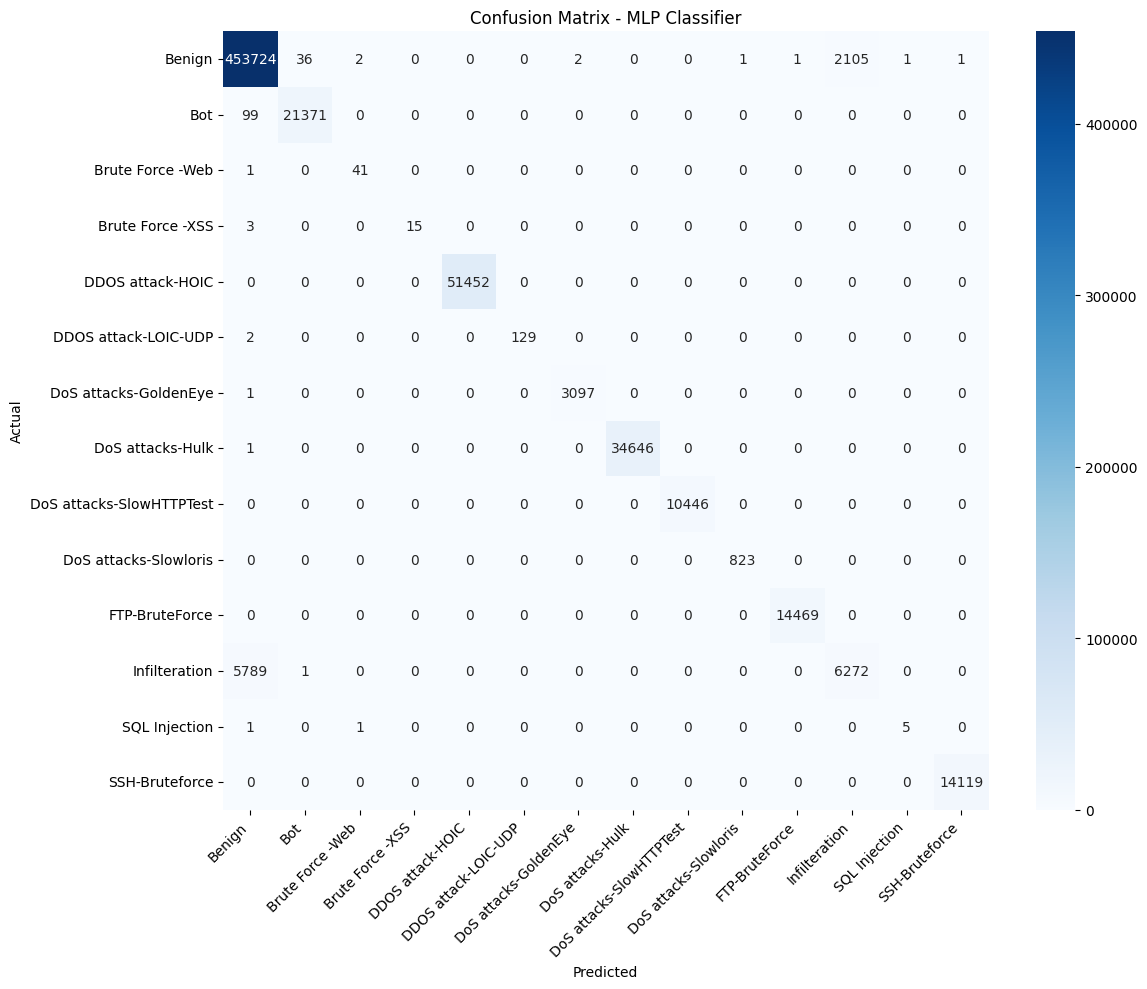


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
      Decision Tree  0.991561   0.991579 0.991561  0.991570
      Random Forest  0.989896   0.989126 0.989896  0.989284
     MLP Classifier  0.986991   0.985572 0.986991  0.985867
Logistic Regression  0.979821   0.977542 0.979821  0.971104


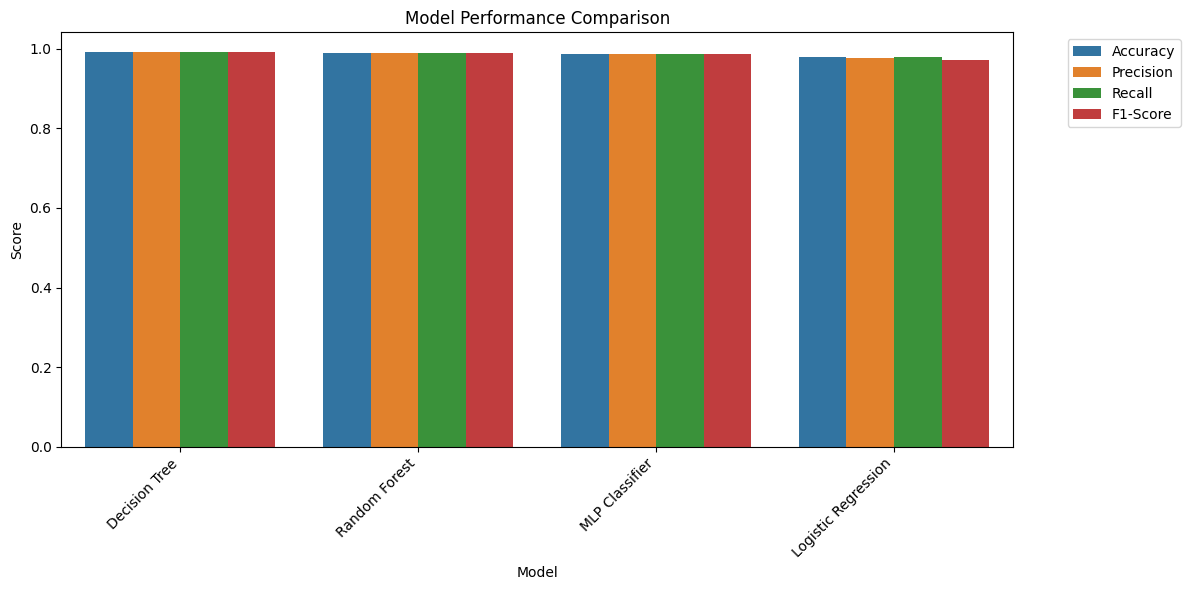


SAVING BEST MODEL
Best model: Decision Tree
Best F1-Score: 0.9916
Best model saved to: /kaggle/working/best_model.pkl
All results saved to: /kaggle/working/model_results.csv

FEATURE IMPORTANCE (Random Forest)

Top 20 most important features:
          feature  importance
         Dst Port    0.094342
             Time    0.081649
             Date    0.060764
Init Fwd Win Byts    0.053431
 Fwd Seg Size Min    0.049538
             Hour    0.049278
        DayOfWeek    0.040299
   Fwd Header Len    0.029856
 Fwd Seg Size Avg    0.027944
  Bwd Pkt Len Max    0.024875
      Pkt Len Std    0.022882
      Active Mean    0.021570
   Bwd Header Len    0.020797
  TotLen Bwd Pkts    0.019990
      Pkt Len Max    0.019954
        Idle Mean    0.019612
 Fwd Pkt Len Mean    0.019574
 Subflow Bwd Byts    0.016659
       Active Std    0.015414
Init Bwd Win Byts    0.015264


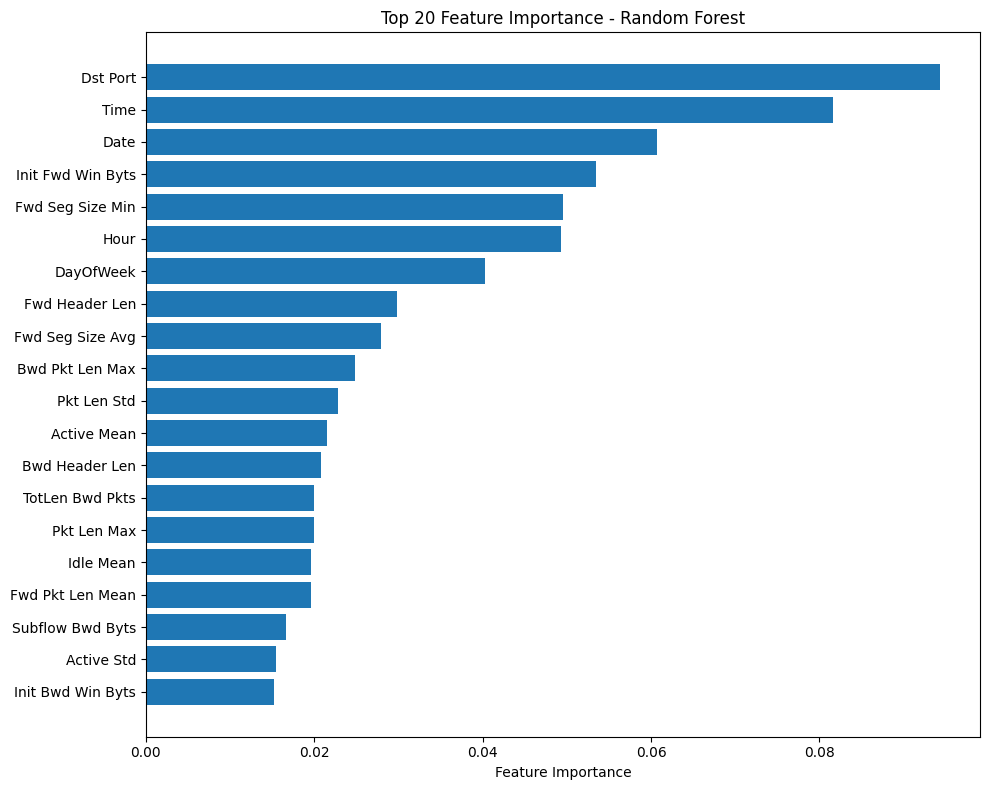


Feature importance saved to: /kaggle/working/feature_importance.csv


In [10]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, classification_report, confusion_matrix)
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n" + "="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

# Load preprocessing objects
print("Loading preprocessing objects...")
scaler = joblib.load('/kaggle/working/scaler.pkl')
label_encoder = joblib.load('/kaggle/working/label_encoder.pkl')
feature_names = joblib.load('/kaggle/working/feature_names.pkl')

# Load processed data
print("Loading processed data...")
X_train_scaled = np.load('/kaggle/working/X_train_scaled.npy')
X_test_scaled = np.load('/kaggle/working/X_test_scaled.npy')
y_train = np.load('/kaggle/working/y_train.npy')
y_test = np.load('/kaggle/working/y_test.npy')

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

# Check which classes are present in test set
unique_train_classes = np.unique(y_train)
unique_test_classes = np.unique(y_test)
print(f"\nClasses in training set: {len(unique_train_classes)}")
print(f"Classes in test set: {len(unique_test_classes)}")

# Identify missing classes in test set
missing_classes = set(unique_train_classes) - set(unique_test_classes)
if missing_classes:
    print(f"\nWarning: {len(missing_classes)} classes missing in test set:")
    for class_idx in missing_classes:
        print(f"  - {label_encoder.classes_[class_idx]}")

# Create filtered label list for classification report
present_classes = sorted(unique_test_classes)
present_class_names = [label_encoder.classes_[i] for i in present_classes]

print(f"\nPresent classes in test set: {present_class_names}")

# Define models to train
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'MLP Classifier': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=500)
}

# Optionally add more models if resources allow
# models['Gradient Boosting'] = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Store results
results = {}
trained_models = {}

# Function to evaluate model
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, class_names):
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print(f"{'='*60}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics with appropriate average for multiclass
    accuracy = accuracy_score(y_test, y_pred)
    
    # Use weighted average for multiclass
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Print results
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # Classification report with only present classes
    print(f"\nClassification Report (only classes present in test set):")
    try:
        # Get unique classes in test set
        present_classes = sorted(np.unique(y_test))
        present_names = [class_names[i] for i in present_classes]
        
        report = classification_report(y_test, y_pred, 
                                      target_names=present_names,
                                      zero_division=0)
        print(report)
    except Exception as e:
        print(f"Could not generate classification report: {e}")
        # Fallback: print simple class distribution
        print("\nPer-class metrics:")
        for class_idx in np.unique(y_test):
            class_name = class_names[class_idx]
            mask = (y_test == class_idx)
            if mask.sum() > 0:
                class_pred = y_pred[mask]
                class_acc = (class_pred == class_idx).sum() / mask.sum()
                print(f"  {class_name}: Accuracy = {class_acc:.4f} ({mask.sum():,} samples)")
    
    # Confusion matrix for all classes (including those with zero samples)
    # Get all possible classes from 0 to max
    all_classes = np.arange(len(class_names))
    cm = confusion_matrix(y_test, y_pred, labels=all_classes)
    
    # Only plot classes that appear in test set
    non_zero_classes = np.where(cm.sum(axis=1) > 0)[0]
    cm_filtered = cm[non_zero_classes][:, non_zero_classes]
    filtered_class_names = [class_names[i] for i in non_zero_classes]
    
    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_filtered, annot=True, fmt='d', cmap='Blues', 
                xticklabels=filtered_class_names,
                yticklabels=filtered_class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred,
        'confusion_matrix': cm
    }

# Train and evaluate each model
for model_name, model in models.items():
    try:
        print(f"\n{'='*60}")
        print(f"Training {model_name}...")
        print(f"{'='*60}")
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Store results
        results[model_name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'y_pred': y_pred
        }
        trained_models[model_name] = model
        
        print(f"\n{model_name} Performance:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        
        # Classification report for present classes
        present_classes = np.unique(y_test)
        present_names = [label_encoder.classes_[i] for i in present_classes]
        
        print(f"\nClassification Report (only classes with test samples):")
        report = classification_report(y_test, y_pred, 
                                      target_names=present_names,
                                      zero_division=0)
        print(report)
        
        # Confusion matrix
        all_classes = np.arange(len(label_encoder.classes_))
        cm = confusion_matrix(y_test, y_pred, labels=all_classes)
        
        # Filter classes with samples
        non_zero_classes = np.where(cm.sum(axis=1) > 0)[0]
        cm_filtered = cm[non_zero_classes][:, non_zero_classes]
        filtered_class_names = [label_encoder.classes_[i] for i in non_zero_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm_filtered, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=filtered_class_names,
                    yticklabels=filtered_class_names)
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error training {model_name}: {e}")
        import traceback
        traceback.print_exc()

# Compare all models
if results:
    print("\n" + "="*80)
    print("MODEL COMPARISON")
    print("="*80)
    
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['accuracy'] for m in results],
        'Precision': [results[m]['precision'] for m in results],
        'Recall': [results[m]['recall'] for m in results],
        'F1-Score': [results[m]['f1'] for m in results]
    })
    
    # Sort by F1-Score
    comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
    print(comparison_df.to_string(index=False))
    
    # Visualize model comparison
    plt.figure(figsize=(12, 6))
    comparison_df_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=comparison_df_melted, x='Model', y='Score', hue='Metric')
    plt.title('Model Performance Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()
    
    # Save the best model
    best_model_name = comparison_df.iloc[0]['Model']
    best_model = results[best_model_name]['model']
    print(f"\n{'='*80}")
    print(f"SAVING BEST MODEL")
    print(f"{'='*80}")
    print(f"Best model: {best_model_name}")
    print(f"Best F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")
    
    # Save best model
    joblib.dump(best_model, '/kaggle/working/best_model.pkl')
    print("Best model saved to: /kaggle/working/best_model.pkl")
    
    # Save all results
    results_df = pd.DataFrame(results).T
    results_df.to_csv('/kaggle/working/model_results.csv')
    print("All results saved to: /kaggle/working/model_results.csv")
    
    # Feature importance for tree-based models
    if 'Random Forest' in results:
        print(f"\n{'='*80}")
        print("FEATURE IMPORTANCE (Random Forest)")
        print(f"{'='*80}")
        
        rf_model = results['Random Forest']['model']
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\nTop 20 most important features:")
        print(feature_importance.head(20).to_string(index=False))
        
        # Plot feature importance
        plt.figure(figsize=(10, 8))
        top_features = feature_importance.head(20)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Feature Importance')
        plt.title('Top 20 Feature Importance - Random Forest')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        # Save feature importance
        feature_importance.to_csv('/kaggle/working/feature_importance.csv', index=False)
        print("\nFeature importance saved to: /kaggle/working/feature_importance.csv")
    
else:
    print("\nNo models were successfully trained.")

# SECTION 6: SAVE BEST MODEL WITH SCALER AND LABEL ENCODER

In [ ]:
print("\n" + "="*80)
print("SAVING MODEL AND PREPROCESSING OBJECTS")
print("="*80)

# Select best model (based on F1-score)
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best model F1-score: {results[best_model_name]['f1']:.4f}")

# Create directory for saving models
model_dir = '/kaggle/working/saved_models'
os.makedirs(model_dir, exist_ok=True)

# Save the best model
model_path = os.path.join(model_dir, f'best_model_{best_model_name.replace(" ", "_")}.pkl')
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path}")

# Save the scaler
scaler_path = os.path.join(model_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

# Save the label encoder
label_encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
joblib.dump(label_encoder, label_encoder_path)
print(f"Label encoder saved to: {label_encoder_path}")

# Save feature names for reference
feature_names_path = os.path.join(model_dir, 'feature_names.txt')
with open(feature_names_path, 'w') as f:
    f.write('\n'.join(X.columns.tolist()))
print(f"Feature names saved to: {feature_names_path}")

# Save model performance summary
performance_path = os.path.join(model_dir, 'model_performance.csv')
comparison_df.to_csv(performance_path, index=False)
print(f"Model performance summary saved to: {performance_path}")

# Save all models (optional)
all_models_path = os.path.join(model_dir, 'all_models.pkl')
joblib.dump(trained_models, all_models_path)
print(f"All models saved to: {all_models_path}")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"""
Training completed successfully!

Saved files:
1. Best model: {best_model_name}
2. Scaler for feature standardization
3. Label encoder for target variable
4. Feature names list
5. Model performance comparison
6. All trained models

File locations: {model_dir}

To load the model for inference:
--------------------------------
import joblib
model = joblib.load('{model_path}')
scaler = joblib.load('{scaler_path}')
label_encoder = joblib.load('{label_encoder_path}')

# Preprocess new data
new_data_scaled = scaler.transform(new_data)
predictions = model.predict(new_data_scaled)
original_labels = label_encoder.inverse_transform(predictions)
""")

# Optional: Test loading the saved model
print("\n" + "="*80)
print("TESTING SAVED MODEL LOADING")
print("="*80)
test_model = joblib.load(model_path)
test_scaler = joblib.load(scaler_path)
test_encoder = joblib.load(label_encoder_path)

# Quick test on test set
sample_indices = np.random.choice(len(X_test_scaled), 5, replace=False)
sample_data = X_test_scaled[sample_indices]
sample_true = y_test.iloc[sample_indices]

predictions = test_model.predict(sample_data)
predicted_labels = test_encoder.inverse_transform(predictions)
true_labels = test_encoder.inverse_transform(sample_true)

print("\nSample predictions:")
for i in range(len(sample_data)):
    print(f"True: {true_labels[i]:<15} | Predicted: {predicted_labels[i]:<15}")

print("\nModel loading test successful!")